In [71]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor




In [72]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [73]:
# Adjust path if needed
features = pd.read_parquet("../../data/processed/market_all_features_with_sentiment.parquet")

features.head()

,date,open,high,low,close,volume,adj close,ticker,sector,cap,return,log_return,year,vol21,vol63,ret_ema21,ret_ema63,px_ma21,px_ma63,px_ma200,trend200_up,sent_mean,sent_std,sent_count,sent_pos,sent_neg,sent_neu,sent_daily_cat,sent_lag1,sent_cat_lag1,sent_roll3,row_id,is_train,set
0,2018-01-04,19.838642,19.958017,19.749111,19.935635,5738092.0,19.935635,ABB,Real Estate - Energy - Industrials,Mid Cap,0.010972,0.010913,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,ABB|2018-01-04,True,train
1,2018-01-04,7.882366,7.882366,7.882366,7.882366,0.0,7.882366,ALPINE,Consumer Discretionary,Large Cap,0.000000,0.000000,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,ALPINE|2018-01-04,True,train
2,2018-01-04,332.666046,333.091339,317.440460,323.224487,111998.0,323.224487,ARYZTA,Consumer Staples,Mid Cap,-0.024390,-0.024693,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.946913,0.0,1.0,1.0,0.0,0.0,positive,0.0,None,0.999941,ARYZTA|2018-01-04,True,train
3,2018-01-04,107.037628,107.741360,106.545007,107.670982,111416.0,107.670982,BALOISE,Insurance,Mid Cap,0.009235,0.009192,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,BALOISE|2018-01-04,True,train
4,2018-01-04,47.071196,47.562372,47.071196,47.480511,19374.0,47.480511,BKW ENERGIE,Real Estate - Energy - Industrials,Small Cap,0.003460,0.003454,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.041373,0.0,1.0,0.0,0.0,1.0,neutral,0.0,None,0.995683,BKW ENERGIE|2018-01-04,True,train


In [74]:
news_counts = features.groupby("ticker")["sent_count"].sum().sort_values(ascending=False)
news_counts


ticker
UBS                 30518.0
SWISSCOM             7052.0
NESTLE               5541.0
VONTOBEL             3208.0
BKW ENERGIE          3164.0
ABB                  3140.0
JULIUS BAER          2717.0
HELVETIA             2216.0
LONZA                2065.0
SWATCH               1952.0
SWISS LIFE           1928.0
SWISS RE             1761.0
HOLCIM               1630.0
ZURICH INSURANCE     1319.0
EMMI                 1297.0
RICHEMONT            1264.0
LOGITECH              969.0
BALOISE               895.0
SWISSQUOTE            887.0
ARYZTA                800.0
GIVAUDAN              770.0
LANDIS                770.0
BLKB                  526.0
SWISS PRIME SITE      438.0
ROCHE                 320.0
NOVARTIS              279.0
ALCON                 240.0
SANTHERA               97.0
ALPINE                 73.0
REISHAUER              67.0
Name: sent_count, dtype: float64

In [75]:
THRESHOLD = 1800
eligible_tickers = news_counts[news_counts >= THRESHOLD].index.tolist()
eligible_tickers


['UBS',
 'SWISSCOM',
 'NESTLE',
 'VONTOBEL',
 'BKW ENERGIE',
 'ABB',
 'JULIUS BAER',
 'HELVETIA',
 'LONZA',
 'SWATCH',
 'SWISS LIFE']

In [76]:
features = features[features["ticker"].isin(eligible_tickers)].copy()

In [77]:
# If some entries are the string "None", turn them into real NaN first (just in case)
features["sent_cat_lag1"] = features["sent_cat_lag1"].replace("None", np.nan)

# 1) Category lag: treat missing as NEUTRAL
features["sent_cat_lag1"] = features["sent_cat_lag1"].fillna("neutral")

# 2) Numeric lag: treat missing as 0 (neutral score)
features["sent_lag1"] = features["sent_lag1"].fillna(0.0)

# 3) Rolling sentiment: also neutral when missing
features["sent_roll3"] = features["sent_roll3"].fillna(0.0)

# Quick check
print(features[["sent_daily_cat", "sent_lag1", "sent_cat_lag1", "sent_roll3"]].head())
print(features[["sent_cat_lag1"]].isna().sum())

   sent_daily_cat  sent_lag1 sent_cat_lag1  sent_roll3
0         neutral        0.0       neutral    0.000000
4         neutral        0.0       neutral    0.995683
8         neutral        0.0       neutral    0.000000
10        neutral        0.0       neutral    0.000000
13        neutral        0.0       neutral    0.000000
sent_cat_lag1    0
dtype: int64


## Create target and lag features

In [78]:
# === 1) Ensure correct ordering ===
features["date"] = pd.to_datetime(features["date"], errors="coerce")

# Sort by ticker and date so shifts are well-defined
features = features.sort_values(["ticker", "date"]).reset_index(drop=True)

# Work on a copy for modeling
features_model = features.copy()

# === 2) Target: next-day return per ticker (t+1) ===
features_model["target_ret_next"] = (
    features_model.groupby("ticker")["return"].shift(-1)
)

# === 3) Autoregressive lags of return (AR(5) style) ===
for lag in range(1, 6):
    features_model[f"ret_lag{lag}"] = (
        features_model.groupby("ticker")["return"].shift(lag)
    )

# === 4) Lagged volatility example ===
features_model["vol21_lag1"] = (
    features_model.groupby("ticker")["vol21"].shift(1)
)

print(features_model.shape)

features_model[[
    "date", "ticker",
    "return", "target_ret_next",
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4", "ret_lag5",
    "vol21", "vol21_lag1"
]].head(10)


(19338, 41)


,date,ticker,return,target_ret_next,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5,vol21,vol21_lag1
0,2018-01-04,ABB,0.010972,0.007485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-05,ABB,0.007485,0.000372,0.010972,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-08,ABB,0.000372,0.005199,0.007485,0.010972,NaN,NaN,NaN,NaN,NaN
3,2018-01-09,ABB,0.005199,-0.007019,0.000372,0.007485,0.010972,NaN,NaN,NaN,NaN
4,2018-01-10,ABB,-0.007019,0.001116,0.005199,0.000372,0.007485,0.010972,NaN,NaN,NaN
5,2018-01-11,ABB,0.001116,0.008175,-0.007019,0.005199,0.000372,0.007485,0.010972,NaN,NaN
6,2018-01-12,ABB,0.008175,-0.007003,0.001116,-0.007019,0.005199,0.000372,0.007485,NaN,NaN
7,2018-01-15,ABB,-0.007003,0.005939,0.008175,0.001116,-0.007019,0.005199,0.000372,NaN,NaN
8,2018-01-16,ABB,0.005939,-0.012546,-0.007003,0.008175,0.001116,-0.007019,0.005199,NaN,NaN
9,2018-01-17,ABB,-0.012546,0.002242,0.005939,-0.007003,0.008175,0.001116,-0.007019,NaN,NaN


## Build train / test DataFrames

In [79]:
# Check that 'set' is present and how it's distributed
print(features_model[["set"]].value_counts())

# Create train / test based on your fixed split
train_df = features_model[features_model["set"] == "train"].copy()
test_df  = features_model[features_model["set"] == "test"].copy()

print("Raw shapes (before dropping NaNs):")
print("train_df:", train_df.shape)
print("test_df :", test_df.shape)

# Columns we *must* have for modeling
required_cols = ["target_ret_next"] + [f"ret_lag{i}" for i in range(1, 6)]
print("Required columns:", required_cols)

# Drop rows with missing target or AR lags *inside each split*
train_df = train_df.dropna(subset=required_cols).copy()
test_df  = test_df.dropna(subset=required_cols).copy()

print("\nAfter dropping rows with missing target/AR lags:")
print("train_df:", train_df.shape)
print("test_df :", test_df.shape)

# Quick preview
train_df[[
    "date", "ticker",
    "return", "target_ret_next",
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4", "ret_lag5"
]].head()


set  
train    13827
test      5511
Name: count, dtype: int64


Raw shapes (before dropping NaNs):
train_df: (13827, 41)
test_df : (5511, 41)
Required columns: ['target_ret_next', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5']

After dropping rows with missing target/AR lags:
train_df: (13772, 41)
test_df : (5500, 41)


,date,ticker,return,target_ret_next,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5
5,2018-01-11,ABB,0.001116,0.008175,-0.007019,0.005199,0.000372,0.007485,0.010972
6,2018-01-12,ABB,0.008175,-0.007003,0.001116,-0.007019,0.005199,0.000372,0.007485
7,2018-01-15,ABB,-0.007003,0.005939,0.008175,0.001116,-0.007019,0.005199,0.000372
8,2018-01-16,ABB,0.005939,-0.012546,-0.007003,0.008175,0.001116,-0.007019,0.005199
9,2018-01-17,ABB,-0.012546,0.002242,0.005939,-0.007003,0.008175,0.001116,-0.007019


## Baseline (Market-Only)

### Define Baseline (Market-Only) Feature Set

In [80]:
# === Baseline (market-only) feature set ===

baseline_features = [
    # Autoregressive return lags
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4", "ret_lag5",

    # Volatility features
    "vol21", "vol63", "vol21_lag1",

    # Trend features
    "ret_ema21", "ret_ema63",
    "px_ma21", "px_ma63", "px_ma200",
    "trend200_up",
]

baseline_features


['ret_lag1',
 'ret_lag2',
 'ret_lag3',
 'ret_lag4',
 'ret_lag5',
 'vol21',
 'vol63',
 'vol21_lag1',
 'ret_ema21',
 'ret_ema63',
 'px_ma21',
 'px_ma63',
 'px_ma200',
 'trend200_up']

### Prepare train/test matrices for Baseline XGBoost

In [81]:
# === Prepare X / y for Baseline XGBoost ===

# Drop rows with NaNs in baseline features or target inside each split
train_base = train_df.dropna(subset=baseline_features + ["target_ret_next"]).copy()
test_base  = test_df.dropna(subset=baseline_features + ["target_ret_next"]).copy()

X_train_base = train_base[baseline_features]
y_train_base = train_base["target_ret_next"]

X_test_base = test_base[baseline_features]
y_test_base = test_base["target_ret_next"]

print("X_train_base shape:", X_train_base.shape)
print("X_test_base shape :", X_test_base.shape)

X_train_base.head()


X_train_base shape: (13134, 14)
X_test_base shape : (5500, 14)


,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5,vol21,vol63,vol21_lag1,ret_ema21,ret_ema63,px_ma21,px_ma63,px_ma200,trend200_up
63,-0.017124,-0.021127,0.010676,0.003571,0.024703,0.012839,0.014356,0.013248,-0.003442,-0.001158,16.910015,18.134221,18.158988,0
64,0.035613,-0.017124,-0.021127,0.010676,0.003571,0.014701,0.015059,0.012839,0.000108,-0.000009,16.908510,18.085875,18.139462,0
65,-0.013755,0.035613,-0.017124,-0.021127,0.010676,0.014945,0.015069,0.014701,-0.001152,-0.000438,16.891678,18.031472,18.117007,0
66,0.010693,-0.013755,0.035613,-0.017124,-0.021127,0.015149,0.015160,0.014945,-0.000075,-0.000090,16.885459,17.979778,18.097882,0
67,0.011960,0.010693,-0.013755,0.035613,-0.017124,0.015076,0.015241,0.015149,0.001019,0.000286,16.877815,17.929622,18.082280,0


### Fit Baseline XGBoost Model

In [82]:
from xgboost import XGBRegressor

# === Baseline XGBoost model (Market-only) ===

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

xgb_base.fit(X_train_base, y_train_base)

y_pred_base = xgb_base.predict(X_test_base)

print("Baseline XGBoost model trained.")


Baseline XGBoost model trained.


### Evaluate Baseline XGBoost

In [83]:
def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

# === Compute metrics ===
mse_base  = mean_squared_error(y_test_base, y_pred_base)
rmse_base = np.sqrt(mse_base)
mae_base  = mean_absolute_error(y_test_base, y_pred_base)
r2_base   = r2_score(y_test_base, y_pred_base)
dir_acc_base = directional_accuracy(y_test_base, y_pred_base)

# === Print results ===
print("=== Baseline XGBoost (Market-only) ===")
print(f"MSE : {mse_base:.6f}")
print(f"RMSE: {rmse_base:.6f}")
print(f"MAE : {mae_base:.6f}")
print(f"R²  : {r2_base:.4f}")
print(f"Directional Accuracy: {dir_acc_base:.4f}")


=== Baseline XGBoost (Market-only) ===
MSE : 0.000227
RMSE: 0.015056
MAE : 0.010149
R²  : -0.0844
Directional Accuracy: 0.4882


### Baseline XGBoost Plots

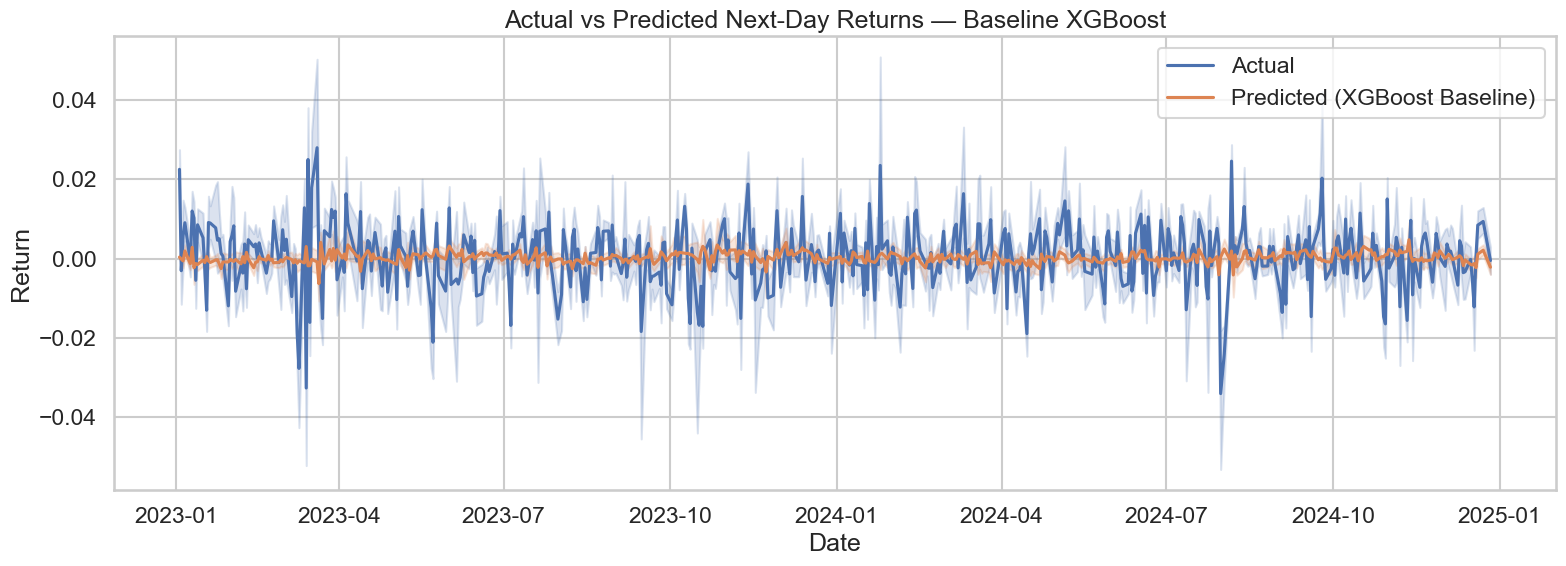

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = test_base.copy()
plot_df["pred_base"] = y_pred_base
plot_df = plot_df.sort_values("date")

sns.set(style="whitegrid", context="talk")

# === 1) Actual vs Predicted Line Plot ===
plt.figure(figsize=(16,6))
sns.lineplot(x="date", y="target_ret_next", data=plot_df, label="Actual")
sns.lineplot(x="date", y="pred_base", data=plot_df, label="Predicted (XGBoost Baseline)")
plt.title("Actual vs Predicted Next-Day Returns — Baseline XGBoost")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

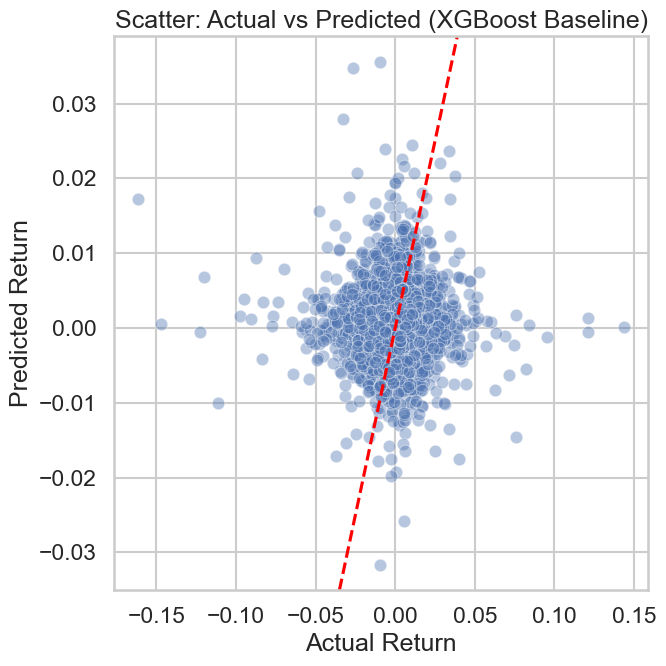

In [85]:
# === 2) Scatter Plot ===
plt.figure(figsize=(7,7))
sns.scatterplot(x=plot_df["target_ret_next"], y=plot_df["pred_base"], alpha=0.4)
plt.axline((0,0), slope=1, color="red", linestyle="--")
plt.title("Scatter: Actual vs Predicted (XGBoost Baseline)")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.tight_layout()
plt.show()

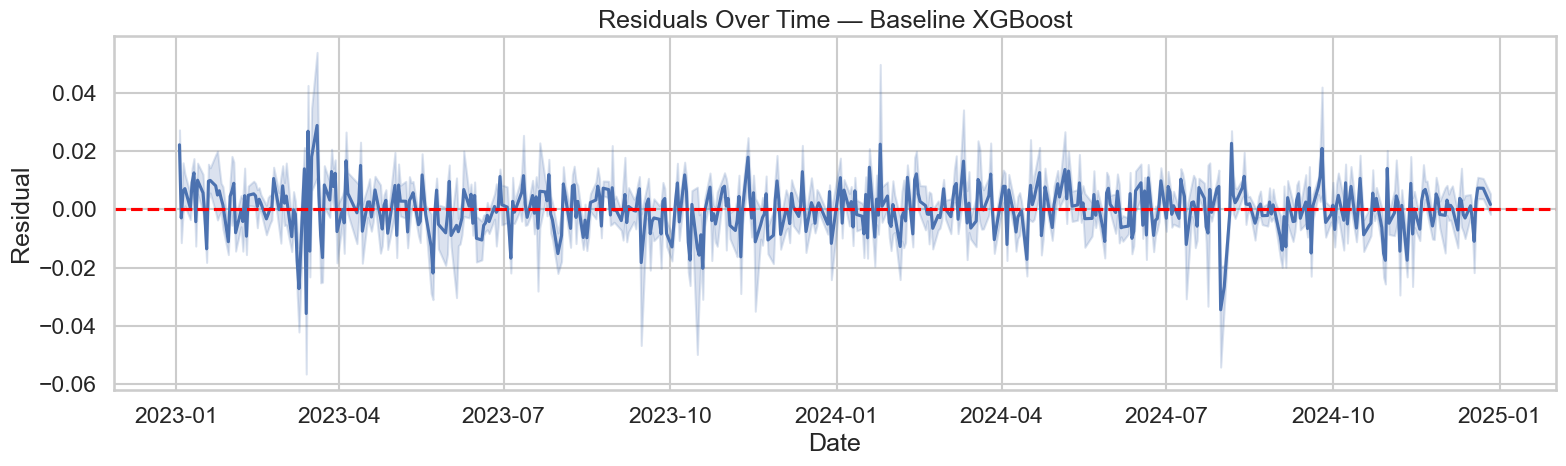

In [86]:
# === 3) Residuals over time ===
plot_df["residual"] = plot_df["target_ret_next"] - plot_df["pred_base"]

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="residual", data=plot_df)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals Over Time — Baseline XGBoost")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

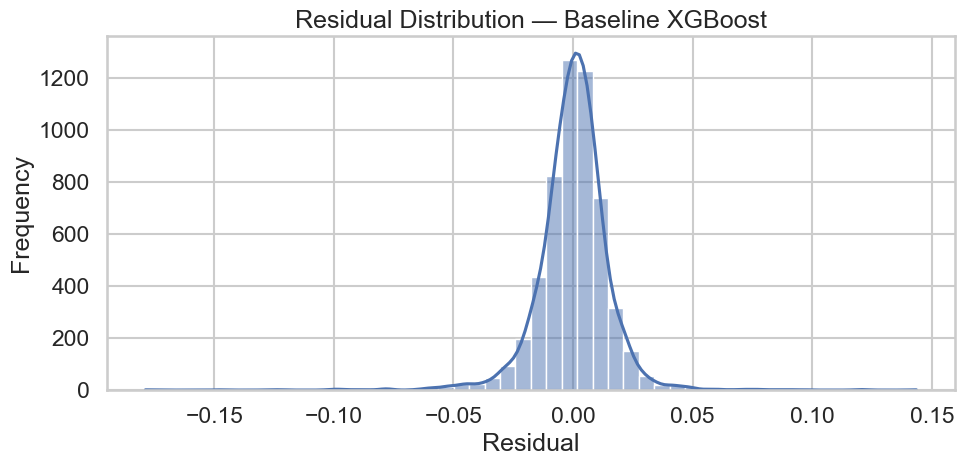

In [87]:
# === 4) Residual distribution ===
plt.figure(figsize=(10,5))
sns.histplot(plot_df["residual"], kde=True, bins=50)
plt.title("Residual Distribution — Baseline XGBoost")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

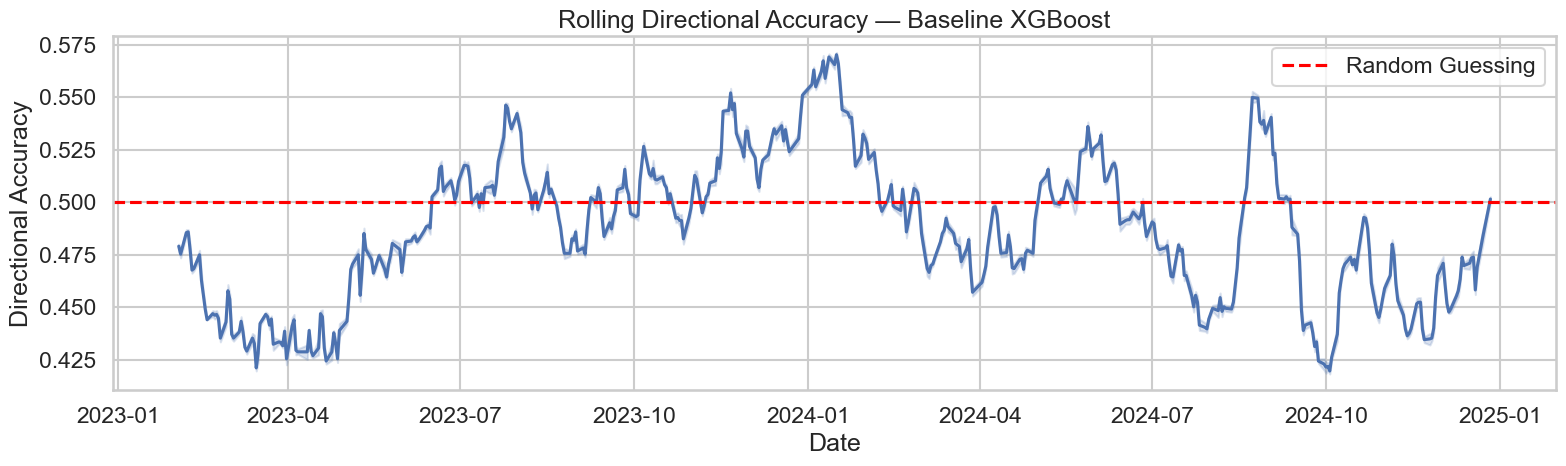

In [88]:
# === 5) Rolling Directional Accuracy (250-day window) ===
plot_df["correct_dir"] = (
    np.sign(plot_df["target_ret_next"]) == np.sign(plot_df["pred_base"])
).astype(int)

plot_df["rolling_dir_acc"] = plot_df["correct_dir"].rolling(250).mean()

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="rolling_dir_acc", data=plot_df)
plt.axhline(0.5, color="red", linestyle="--", label="Random Guessing")
plt.title("Rolling Directional Accuracy — Baseline XGBoost")
plt.xlabel("Date")
plt.ylabel("Directional Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [89]:
# Sample check of actual vs predicted values
sample_base = plot_df[[
    "date",
    "ticker",
    "target_ret_next",
    "pred_base",
    "residual"
]].head(30)

sample_base


,date,ticker,target_ret_next,pred_base,residual
1257,2023-01-03,ABB,0.033751,-0.001864,0.035615
8289,2023-01-03,LONZA,0.015398,0.000740,0.014658
6531,2023-01-03,JULIUS BAER,0.023491,0.000847,0.022644
15321,2023-01-03,SWISSCOM,0.010861,0.000232,0.010630
4773,2023-01-03,HELVETIA,0.019022,-0.000096,0.019117
11805,2023-01-03,SWATCH,0.019834,0.002429,0.017405
10047,2023-01-03,NESTLE,0.017260,0.000335,0.016925
18837,2023-01-03,VONTOBEL,0.030255,0.002117,0.028138
3015,2023-01-03,BKW ENERGIE,0.038251,-0.000413,0.038665
13563,2023-01-03,SWISS LIFE,0.016803,-0.000584,0.017387


## Multimodal (with sentiment)

### Define Multimodal Feature Set (Market + Sentiment)

In [90]:
# Map sentiment categories to numeric
sent_map = {"negative": -1, "neutral": 0, "positive": 1}
train_df["sent_cat_lag1_num"] = train_df["sent_cat_lag1"].map(sent_map)
test_df["sent_cat_lag1_num"] = test_df["sent_cat_lag1"].map(sent_map)

# === Multimodal feature set (market + sentiment) ===
multimodal_features = baseline_features + [
    "sent_lag1",          # numeric sentiment t-1
    "sent_cat_lag1_num",  # categorical sentiment mapped to integer
    "sent_roll3"          # rolling sentiment feature
]

multimodal_features


['ret_lag1',
 'ret_lag2',
 'ret_lag3',
 'ret_lag4',
 'ret_lag5',
 'vol21',
 'vol63',
 'vol21_lag1',
 'ret_ema21',
 'ret_ema63',
 'px_ma21',
 'px_ma63',
 'px_ma200',
 'trend200_up',
 'sent_lag1',
 'sent_cat_lag1_num',
 'sent_roll3']

### Prepare X / y for Multimodal XGBoost

In [91]:
# Drop rows with NaNs in multimodal features or target inside each split
train_mm = train_df.dropna(subset=multimodal_features + ["target_ret_next"]).copy()
test_mm  = test_df.dropna(subset=multimodal_features + ["target_ret_next"]).copy()

X_train_mm = train_mm[multimodal_features]
y_train_mm = train_mm["target_ret_next"]

X_test_mm = test_mm[multimodal_features]
y_test_mm = test_mm["target_ret_next"]

print("X_train_mm shape:", X_train_mm.shape)
print("X_test_mm shape :", X_test_mm.shape)

X_train_mm.head()


X_train_mm shape: (13134, 17)
X_test_mm shape : (5500, 17)


,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5,vol21,vol63,vol21_lag1,ret_ema21,ret_ema63,px_ma21,px_ma63,px_ma200,trend200_up,sent_lag1,sent_cat_lag1_num,sent_roll3
63,-0.017124,-0.021127,0.010676,0.003571,0.024703,0.012839,0.014356,0.013248,-0.003442,-0.001158,16.910015,18.134221,18.158988,0,0.000000,0,0.000000
64,0.035613,-0.017124,-0.021127,0.010676,0.003571,0.014701,0.015059,0.012839,0.000108,-0.000009,16.908510,18.085875,18.139462,0,0.984477,1,0.991983
65,-0.013755,0.035613,-0.017124,-0.021127,0.010676,0.014945,0.015069,0.014701,-0.001152,-0.000438,16.891678,18.031472,18.117007,0,0.846902,1,0.943783
66,0.010693,-0.013755,0.035613,-0.017124,-0.021127,0.015149,0.015160,0.014945,-0.000075,-0.000090,16.885459,17.979778,18.097882,0,0.946340,1,0.925906
67,0.011960,0.010693,-0.013755,0.035613,-0.017124,0.015076,0.015241,0.015149,0.001019,0.000286,16.877815,17.929622,18.082280,0,0.950856,1,0.914699


### Train Multimodal XGBoost (Market + Sentiment)

In [92]:
# === Multimodal XGBoost model (Market + Sentiment) ===

xgb_mm = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

xgb_mm.fit(X_train_mm, y_train_mm)

y_pred_mm = xgb_mm.predict(X_test_mm)

print("Multimodal XGBoost model trained.")


Multimodal XGBoost model trained.


### Multimodal metrics (RMSE, MAE, R², DirAcc)

In [93]:
# === Multimodal evaluation ===
mse_mm  = mean_squared_error(y_test_mm, y_pred_mm)
rmse_mm = np.sqrt(mse_mm)
mae_mm  = mean_absolute_error(y_test_mm, y_pred_mm)
r2_mm   = r2_score(y_test_mm, y_pred_mm)
dir_acc_mm = directional_accuracy(y_test_mm, y_pred_mm)

print("=== XGBoost + Sentiment (Multimodal) ===")
print(f"MSE : {mse_mm:.6f}")
print(f"RMSE: {rmse_mm:.6f}")
print(f"MAE : {mae_mm:.6f}")
print(f"R²  : {r2_mm:.4f}")
print(f"Directional Accuracy: {dir_acc_mm:.4f}")


=== XGBoost + Sentiment (Multimodal) ===
MSE : 0.000226
RMSE: 0.015020
MAE : 0.010074
R²  : -0.0792
Directional Accuracy: 0.4895


### Multimodal XGBoost Plots

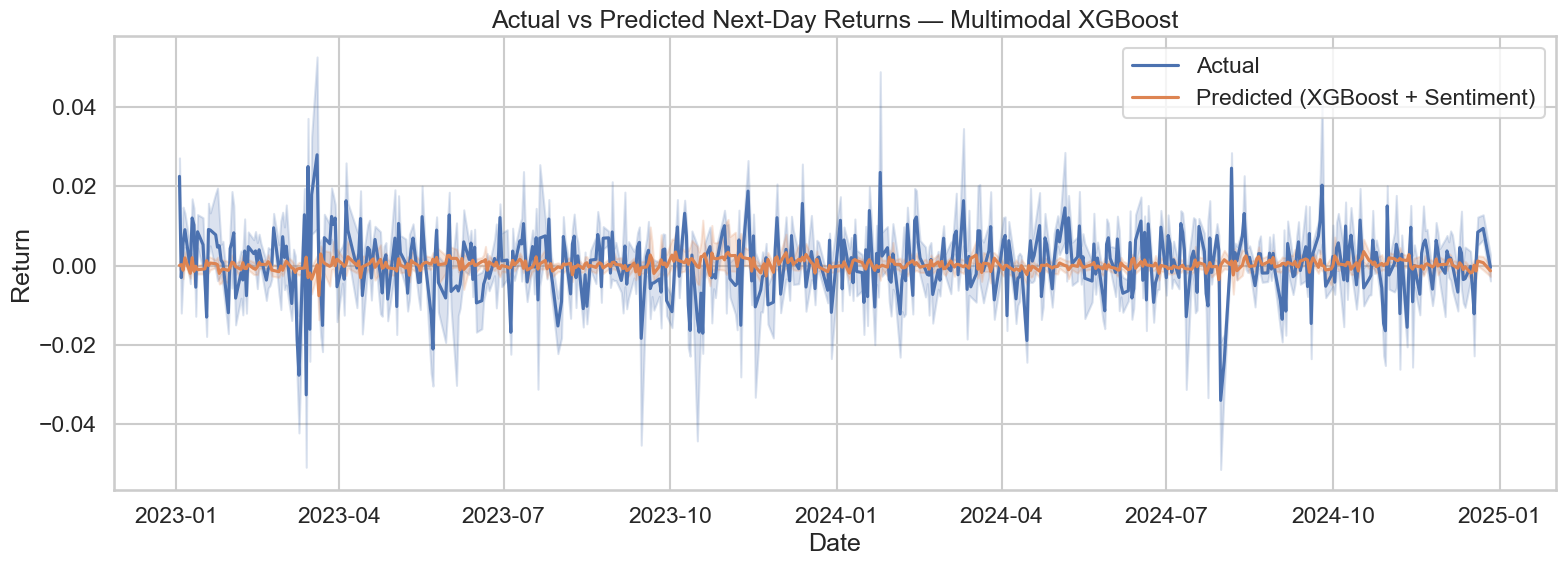

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_mm = test_mm.copy()
plot_mm["pred_mm"] = y_pred_mm
plot_mm = plot_mm.sort_values("date")

sns.set(style="whitegrid", context="talk")

# === 1) Actual vs Predicted Line Plot ===
plt.figure(figsize=(16,6))
sns.lineplot(x="date", y="target_ret_next", data=plot_mm, label="Actual")
sns.lineplot(x="date", y="pred_mm", data=plot_mm, label="Predicted (XGBoost + Sentiment)")
plt.title("Actual vs Predicted Next-Day Returns — Multimodal XGBoost")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

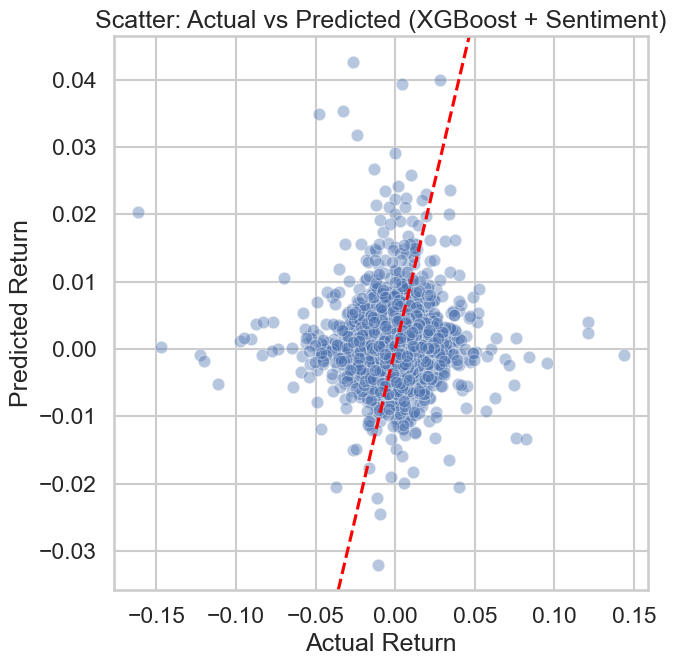

In [95]:
# === 2) Scatter Plot ===
plt.figure(figsize=(7,7))
sns.scatterplot(x=plot_mm["target_ret_next"], y=plot_mm["pred_mm"], alpha=0.4)
plt.axline((0,0), slope=1, color="red", linestyle="--")
plt.title("Scatter: Actual vs Predicted (XGBoost + Sentiment)")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.tight_layout()
plt.show()  

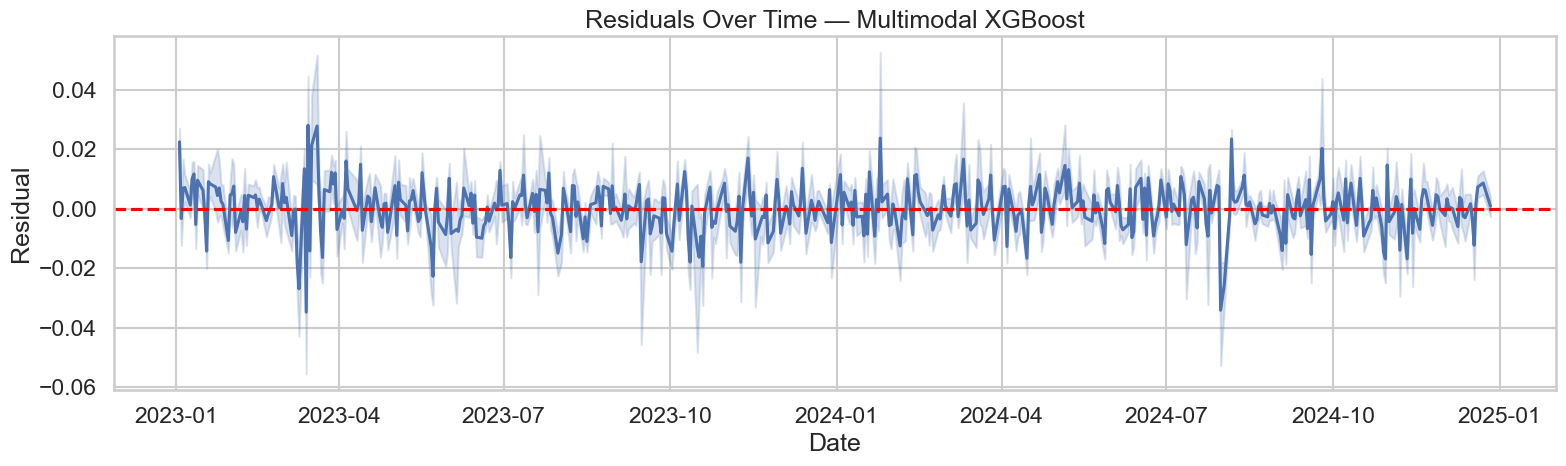

In [96]:
# === 3) Residuals Over Time ===
plot_mm["residual_mm"] = plot_mm["target_ret_next"] - plot_mm["pred_mm"]

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="residual_mm", data=plot_mm)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals Over Time — Multimodal XGBoost")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

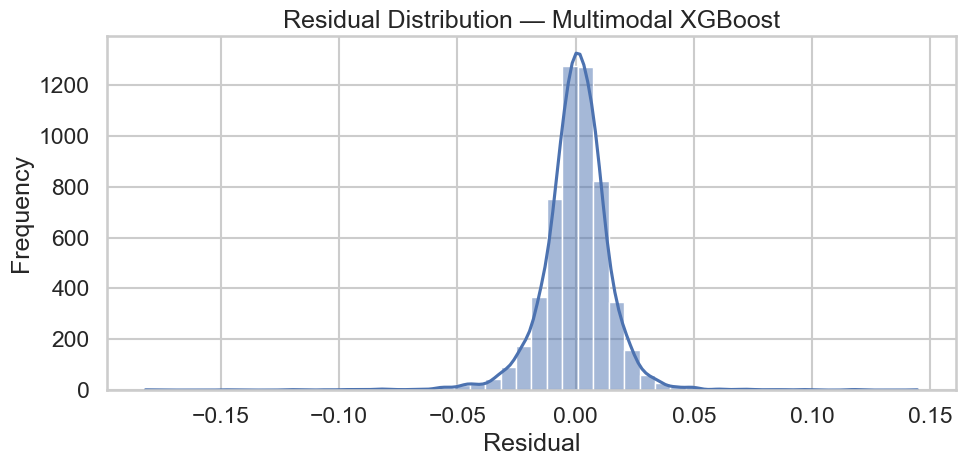

In [97]:
# === 4) Residual Distribution ===
plt.figure(figsize=(10,5))
sns.histplot(plot_mm["residual_mm"], kde=True, bins=50)
plt.title("Residual Distribution — Multimodal XGBoost")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

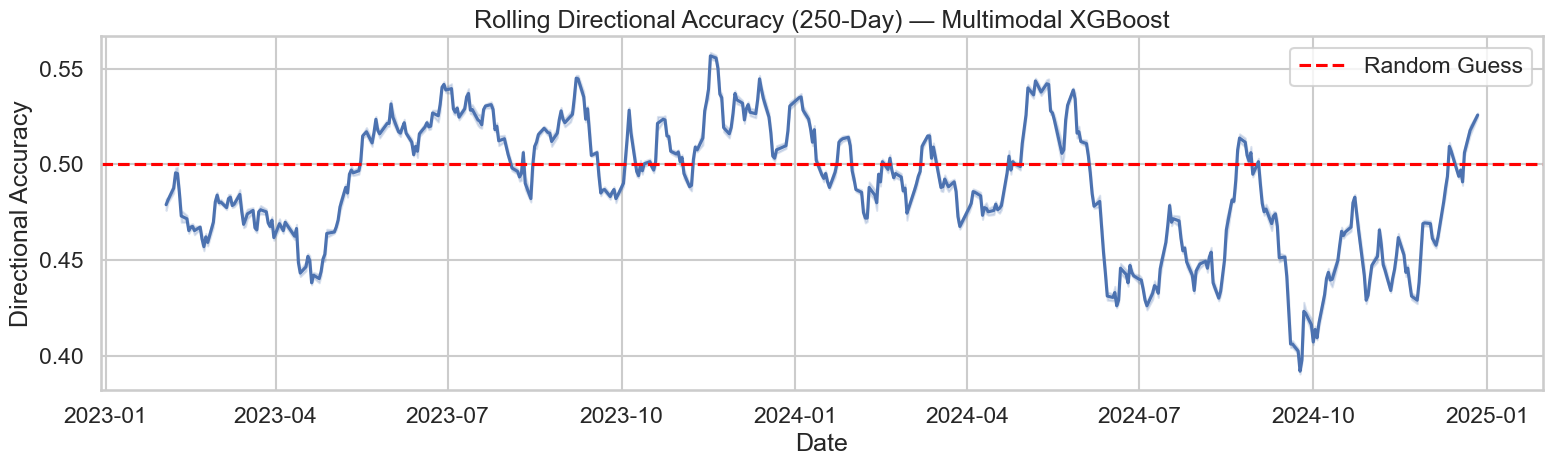

In [98]:
# === 5) Rolling Directional Accuracy ===
plot_mm["correct_dir_mm"] = (
    np.sign(plot_mm["target_ret_next"]) == np.sign(plot_mm["pred_mm"])
).astype(int)

plot_mm["rolling_dir_acc_mm"] = plot_mm["correct_dir_mm"].rolling(250).mean()

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="rolling_dir_acc_mm", data=plot_mm)
plt.axhline(0.5, color="red", linestyle="--", label="Random Guess")
plt.title("Rolling Directional Accuracy (250-Day) — Multimodal XGBoost")
plt.xlabel("Date")
plt.ylabel("Directional Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [99]:
sample_mm = plot_mm[[
    "date",
    "ticker",
    "target_ret_next",
    "pred_mm",
    "residual_mm"
]].head(30)

sample_mm


,date,ticker,target_ret_next,pred_mm,residual_mm
1257,2023-01-03,ABB,0.033751,-0.000781,0.034532
8289,2023-01-03,LONZA,0.015398,-0.003686,0.019084
6531,2023-01-03,JULIUS BAER,0.023491,-0.000486,0.023977
15321,2023-01-03,SWISSCOM,0.010861,0.001495,0.009366
4773,2023-01-03,HELVETIA,0.019022,-0.000104,0.019126
11805,2023-01-03,SWATCH,0.019834,0.002439,0.017395
10047,2023-01-03,NESTLE,0.017260,-0.001652,0.018913
18837,2023-01-03,VONTOBEL,0.030255,-0.000084,0.030339
3015,2023-01-03,BKW ENERGIE,0.038251,0.002561,0.035690
13563,2023-01-03,SWISS LIFE,0.016803,-0.001319,0.018122


## Analysis

In [100]:
from sklearn.metrics import mean_squared_error

# Start from baseline test set
cmp = test_base[["row_id", "date", "ticker", "target_ret_next"]].copy()
cmp["pred_base"] = y_pred_base

# Add multimodal predictions (matched by row_id)
tmp_mm = test_mm[["row_id"]].copy()
tmp_mm["pred_mm"] = y_pred_mm

cmp = cmp.merge(tmp_mm, on="row_id", how="inner")

# Quick sanity check
cmp.head()


,row_id,date,ticker,target_ret_next,pred_base,pred_mm
0,ABB|2023-01-03,2023-01-03,ABB,0.033751,-0.001864,-0.000781
1,ABB|2023-01-04,2023-01-04,ABB,0.000673,-0.000193,-0.001428
2,ABB|2023-01-05,2023-01-05,ABB,0.009418,0.000565,-0.002631
3,ABB|2023-01-06,2023-01-06,ABB,0.014329,0.004080,0.004261
4,ABB|2023-01-09,2023-01-09,ABB,-0.006570,0.002000,0.001450


### Per Company metrics

In [101]:
company_metrics = (
    cmp.groupby("ticker")
       .apply(lambda df: pd.Series({
           "RMSE_base":  np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_base"])),
           "RMSE_mm":    np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_mm"])),
           "DirAcc_base": np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_base"])),
           "DirAcc_mm":   np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_mm"])),
       }))
       .reset_index()
)

company_metrics_sorted = company_metrics.sort_values("DirAcc_mm", ascending=False)

company_metrics_sorted



C:\Users\mkcak\AppData\Local\Temp\ipykernel_18084\4088515520.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,ticker,RMSE_base,RMSE_mm,DirAcc_base,DirAcc_mm
9,UBS,0.018024,0.017801,0.526,0.546
5,NESTLE,0.010036,0.009997,0.500,0.508
2,HELVETIA,0.011800,0.011729,0.466,0.502
4,LONZA,0.021755,0.022329,0.508,0.496
7,SWISS LIFE,0.012036,0.011883,0.512,0.494
0,ABB,0.014168,0.014023,0.484,0.492
6,SWATCH,0.018067,0.017811,0.442,0.490
3,JULIUS BAER,0.018230,0.018051,0.498,0.482
1,BKW ENERGIE,0.014684,0.014614,0.502,0.466
8,SWISSCOM,0.008821,0.008610,0.480,0.460


### CAP-LEVEL Metrics (Small / Mid / Large Cap)

In [102]:
# Attach cap info to cmp using row_id
cmp_cap = cmp.merge(
    features_model[["row_id", "cap"]],
    on="row_id",
    how="left"
)

cap_metrics = (
    cmp_cap.groupby("cap")
           .apply(lambda df: pd.Series({
               "RMSE_base":  np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_base"])),
               "RMSE_mm":    np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_mm"])),
               "DirAcc_base": np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_base"])),
               "DirAcc_mm":   np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_mm"])),
           }))
           .reset_index()
)

cap_metrics


C:\Users\mkcak\AppData\Local\Temp\ipykernel_18084\32510955.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,cap,RMSE_base,RMSE_mm,DirAcc_base,DirAcc_mm
0,Large Cap,0.015447,0.015281,0.5050,0.4880
1,Mid Cap,0.014168,0.014023,0.4840,0.4920
2,Small Cap,0.015065,0.015074,0.4845,0.4895


### Sector-level metrics

In [103]:
# Attach sector info using row_id
cmp_sector = cmp.merge(
    features_model[["row_id", "sector"]],
    on="row_id",
    how="left"
)

sector_metrics = (
    cmp_sector.groupby("sector")
              .apply(lambda df: pd.Series({
                  "RMSE_base":  np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_base"])),
                  "RMSE_mm":    np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_mm"])),
                  "DirAcc_base": np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_base"])),
                  "DirAcc_mm":   np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_mm"])),
              }))
              .reset_index()
)

sector_metrics.sort_values("DirAcc_mm", ascending=False)


C:\Users\mkcak\AppData\Local\Temp\ipykernel_18084\3427788125.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,sector,RMSE_base,RMSE_mm,DirAcc_base,DirAcc_mm
2,Consumer Staples,0.010036,0.009997,0.500,0.508
4,Insurance,0.011919,0.011806,0.489,0.498
3,Health Care,0.021755,0.022329,0.508,0.496
0,Banking,0.016481,0.016357,0.492,0.492
1,Consumer Discretionary,0.018067,0.017811,0.442,0.490
5,Real Estate - Energy - Industrials,0.014428,0.014322,0.493,0.479
6,Technology,0.008821,0.008610,0.480,0.460
